In [52]:
import os
import numpy as np
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Patch for NumPy compatibility
np.complex = complex

# === SETTINGS ===
folder_path = r"C:\Users\amiru\OneDrive\Desktop\An-Nas_HF_Audio_AUG"
verse_map = {
    "قُلۡ أَعُوذُ بِرَبِّ ٱلنَّاسِ": 1,
    "مَلِكِ ٱلنَّاسِ": 2,
    "إِلَـٰهِ ٱلنَّاسِ": 3,
    "مِن شَرِّ ٱلۡوَسۡوَاسِ ٱلۡخَنَّاسِ": 4,
    "ٱلَّذِی یُوَسۡوِسُ فِی صُدُورِ ٱلنَّاسِ": 5,
    "مِنَ ٱلۡجِنَّةِ وَٱلنَّاسِ": 6
}
n_mels = 60
max_len = 100

# === FEATURE EXTRACTION ===
X, y = [], []
for file in os.listdir(folder_path):
    if not file.endswith(".wav"): continue
    label = next((v for k, v in verse_map.items() if k in file), None)
    if label is None: continue

    try:
        y_raw, sr = librosa.load(os.path.join(folder_path, file), sr=16000)
        mel = librosa.feature.melspectrogram(y=y_raw, sr=sr, n_mels=n_mels)
        log_mel = librosa.power_to_db(mel).T

        # Pad/truncate
        if log_mel.shape[0] < max_len:
            log_mel = np.pad(log_mel, ((0, max_len - log_mel.shape[0]), (0, 0)), mode='constant')
        else:
            log_mel = log_mel[:max_len, :]

        log_mel = (log_mel - np.mean(log_mel)) / np.std(log_mel)

        X.append(log_mel)
        y.append(label)
    except Exception as e:
        print(f"Error in {file}: {e}")

X = np.array(X)
y = np.array(y)
np.save("X_annas_mel.npy", X)
np.save("y_annas_labels.npy", y)

print(f"✅ Saved {X.shape[0]} samples, shape {X.shape[1:]} (time_steps, features)")


✅ Saved 1671 samples, shape (100, 60) (time_steps, features)


In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Load data
X = (X - np.mean(X)) / np.std(X)
y_cat = to_categorical(y - 1)

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X.shape[1], X.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(y_cat.shape[1], activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=8, callbacks=[early_stop])
model.save("bilstm_annas_classifier.keras")


Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.2300 - loss: 1.8222 - val_accuracy: 0.3134 - val_loss: 1.6299
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.3640 - loss: 1.5047 - val_accuracy: 0.3172 - val_loss: 1.5951
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.3500 - loss: 1.5496 - val_accuracy: 0.3433 - val_loss: 1.5871
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.3920 - loss: 1.4300 - val_accuracy: 0.3358 - val_loss: 1.6535
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4045 - loss: 1.3739 - val_accuracy: 0.3806 - val_loss: 1.6432
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4494 - loss: 1.3253 - val_accuracy: 0.3657 - val_loss: 1.6529
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4681 - loss: 1.3074 - val_accuracy: 0.3918 - val_loss: 1.6216
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.4533 - loss: 1.2701 - val_acc

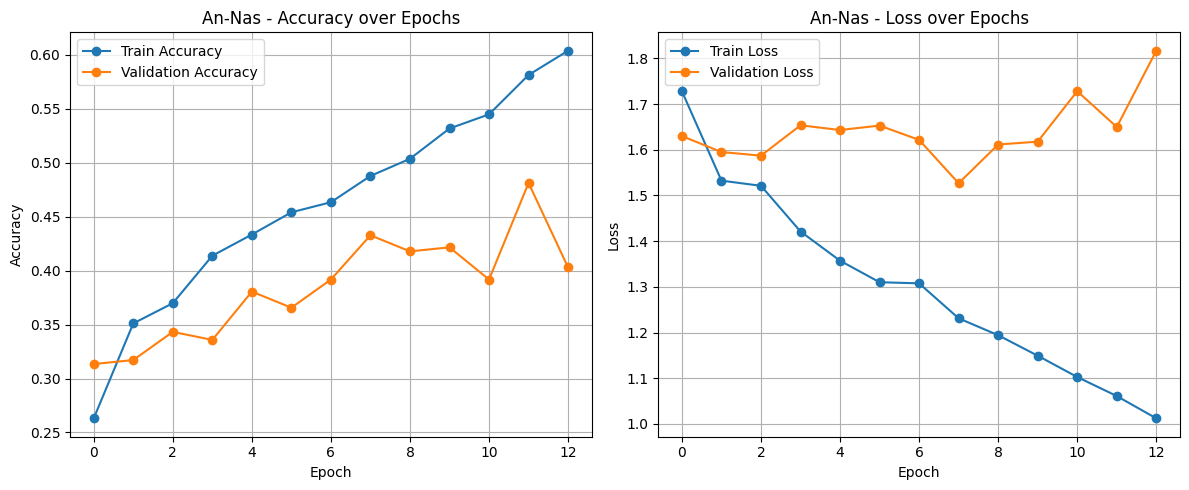

In [54]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('An-Nas - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('An-Nas - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import os
import pyaudio
import numpy as np
import librosa
import threading
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("bilstm_annas_classifier.keras")

# Verse mapping
verse_texts = {
    1: "قُلْ أَعُوذُ بِرَبِّ النَّاسِ",
    2: "مَلِكِ النَّاسِ",
    3: "إِلَٰهِ النَّاسِ",
    4: "مِنْ شَرِّ الْوَسْوَاسِ الْخَنَّاسِ",
    5: "الَّذِي يُوَسْوِسُ فِي صُدُورِ النَّاسِ",
    6: "مِنَ الْجِنَّةِ وَالنَّاسِ"
}

# Settings
RATE = 16000
CHUNK_DURATION = 2  # seconds
CHUNK_SIZE = RATE * CHUNK_DURATION
N_MELS = 60
MAX_LEN = 100
CONFIDENCE_THRESHOLD = 0.4  # For debugging

stop_flag = False
highlighted_verses = set()
best_prediction = None
best_confidence = 0.0

def wait_for_stop():
    global stop_flag
    input("🔘 Press Enter to stop recitation...\n")
    stop_flag = True

def extract_features(audio_data):
    y_trimmed, _ = librosa.effects.trim(audio_data, top_db=25)
    if len(y_trimmed) == 0:
        return None

    # Mel-spectrogram
    mel = librosa.feature.melspectrogram(y=y_trimmed, sr=RATE, n_mels=N_MELS)
    log_mel = librosa.power_to_db(mel)

    # Δ and ΔΔ
    delta = librosa.feature.delta(log_mel)
    delta2 = librosa.feature.delta(log_mel, order=2)

    # Combine features [mel | delta | delta2]
    combined = np.concatenate([log_mel, delta, delta2], axis=0).T  # shape: (time, features)

    # Pad or truncate
    if combined.shape[0] < MAX_LEN:
        combined = np.pad(combined, ((0, MAX_LEN - combined.shape[0]), (0, 0)), mode='constant')
    else:
        combined = combined[:MAX_LEN, :]

    # Normalize
    combined = (combined - np.mean(combined)) / np.std(combined)
    return np.expand_dims(combined, axis=0)

def predict_chunk(audio_data):
    features = extract_features(audio_data)
    if features is None:
        return None, 0.0

    prediction = model.predict(features, verbose=0)
    predicted_class = np.argmax(prediction) + 1
    confidence = np.max(prediction)

    print(f"[🔍] Prediction vector: {np.round(prediction[0], 3)}")
    print(f"[ℹ️] Predicted class: {predicted_class} | Confidence: {confidence:.2f}")

    return predicted_class, confidence

def display_verses(highlight_id=None):
    os.system('cls' if os.name == 'nt' else 'clear')
    print("\n📖 Surah An-Nas\n")
    for i in range(1, 7):
        verse = verse_texts[i]
        if i == highlight_id:
            print(f">>> 🟢 {verse} <<<")
        elif i in highlighted_verses:
            print(f"✅ {verse}")
        else:
            print(f"⬜ {verse}")
    print("\n🎧 Listening...")

# Start PyAudio stream
p = pyaudio.PyAudio()
stream = p.open(format=pyaudio.paInt16,
                channels=1,
                rate=RATE,
                input=True,
                frames_per_buffer=CHUNK_SIZE)

listener_thread = threading.Thread(target=wait_for_stop)
listener_thread.start()

print("🎙️ Real-Time Surah An-Nas Recitation Detection Started...\n")
display_verses()

try:
    while not stop_flag:
        audio_data = stream.read(CHUNK_SIZE, exception_on_overflow=False)
        audio_np = np.frombuffer(audio_data, dtype=np.int16).astype(np.float32) / 32768.0

        predicted_class, confidence = predict_chunk(audio_np)

        if predicted_class and confidence > CONFIDENCE_THRESHOLD:
            if confidence > best_confidence:
                best_prediction = predicted_class
                best_confidence = confidence

            highlighted_verses.add(predicted_class)
            display_verses(highlight_id=predicted_class)
        elif confidence < 0.2:
            print("[⚠️] Very low confidence — input might be silent or unclear.")

except Exception as e:
    print(f"\n❌ Error: {e}")

finally:
    stream.stop_stream()
    stream.close()
    p.terminate()

    print("\n🛑 Recitation ended by user.")
    if best_prediction:
        print(f"\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
        print(f"✅ Most Confident Verse: V{best_prediction} | Confidence: {best_confidence:.2f}")
        print(f"🕋 {verse_texts[best_prediction]}")
    else:
        print("⚠️ No confident verse detected.")


🎙️ Real-Time Surah An-Nas Recitation Detection Started...


📖 Surah An-Nas

⬜ قُلْ أَعُوذُ بِرَبِّ النَّاسِ
⬜ مَلِكِ النَّاسِ
⬜ إِلَٰهِ النَّاسِ
⬜ مِنْ شَرِّ الْوَسْوَاسِ الْخَنَّاسِ
⬜ الَّذِي يُوَسْوِسُ فِي صُدُورِ النَّاسِ
⬜ مِنَ الْجِنَّةِ وَالنَّاسِ

🎧 Listening...
